#### Data from Four Exchanges, from 9/1 to 9/7.
9/1 to 9/5: train data, 9/6: validation data, 9/7: test data

### Cell 1-2: Setups
### Cell 3: Useful Functions
### Cell 4-7: Read Data + Create Single Exchange Features
### Cell 8: Generate Feature Parquet and Labels by Day
### Cell 9-11: Combine Cross Exchange Data 

In [1]:
from pathlib import Path
import re
import gc
import math
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from tqdm.auto import tqdm

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 200)

# =========================================================
# CHANGE THIS
# =========================================================
ROOT = Path("/Volumes/TOSHIBA EXT/URES")

DATES = ["20240901", "20240902", "20240903", "20240904", "20240905", "20240906", "20240907"]

DATE_TO_SPLIT = {
    "20240901": "train",
    "20240902": "train",
    "20240903": "train",
    "20240904": "train",
    "20240905": "train",
    "20240906": "val",
    "20240907": "test",
}

TS_COL = "exchange_ts"

GRID = "200ms"
DT_S = pd.to_timedelta(GRID).total_seconds()

L = 20
LAGS = [1, 2, 3, 5, 10, 20, 50, 100]

WIN_SEC = [1, 5, 10, 30, 60]
DEPTH_LIST = [1, 5, 10, 20]

HORIZON_S = 5
HORIZON_STEPS = int(round(HORIZON_S / DT_S))
assert HORIZON_STEPS == 25

TRIM_START_MIN = 30
TRIM_END_MIN = 23 * 60 + 30

KEEP_DF_ALL_IN_MEMORY = False
ONLY_TARGET = None
LOW_MEM_STREAMING = True

OUT_DIR = ROOT / "out_merged_20240901_20240904_200ms"
OUT_DIR.mkdir(parents=True, exist_ok=True)

EXCHANGES = ["Binance", "Bybit", "OKX", "GateIO"]

FILE_TEMPLATES = {
    "Binance": "BTCUSDT_BinanceUSDM_{date}_{hour}_orderbook.parquet.gzip",
    "Bybit":   "BTCUSDT_BybitLinear_Public_{date}_{hour}_orderbook.parquet.gzip",
    "OKX":     "BTC-USDT-SWAP_OKXPerp_{date}_{hour}_orderbook.parquet.gzip",
    "GateIO":  "BTC_USDT_GateIOFutures_{date}_{hour}_orderbook.parquet.gzip",
}

print("ROOT =", ROOT)
print("OUT_DIR =", OUT_DIR)
print("DATES =", DATES)
print("DATE_TO_SPLIT =", DATE_TO_SPLIT)

ROOT = /Volumes/TOSHIBA EXT/URES
OUT_DIR = /Volumes/TOSHIBA EXT/URES/out_merged_20240901_20240904_200ms
DATES = ['20240901', '20240902', '20240903', '20240904', '20240905', '20240906', '20240907']
DATE_TO_SPLIT = {'20240901': 'train', '20240902': 'train', '20240903': 'train', '20240904': 'train', '20240905': 'train', '20240906': 'val', '20240907': 'test'}


In [2]:
def build_hour_path(exchange: str, date_str: str, hour: int) -> Path:
    name = FILE_TEMPLATES[exchange].format(date=date_str, hour=hour)
    return ROOT / f"{date_str}_crypto" / name

def book_columns(depth=20):
    cols = [TS_COL]
    for i in range(depth):
        cols += [f"a{i}_px", f"a{i}_qty", f"b{i}_px", f"b{i}_qty"]
    return cols

In [3]:
def pick_timestamp_columns(df, candidates=None, primary_preference="exchange_ts"):
    if candidates is None:
        candidates = ["exchange_ts", "timestamp", "ts", "time", "capture_ts_ns", "create_ts"]

    present = [c for c in candidates if c in df.columns]

    if primary_preference in df.columns:
        return primary_preference, present

    if len(present) > 0:
        return present[0], present

    fuzzy = [c for c in df.columns if any(k in c.lower() for k in ["ts", "time", "stamp"])]
    if len(fuzzy) > 0:
        return fuzzy[0], fuzzy

    return None, []


def to_datetime_auto(x):
    s = pd.Series(x)
    s_num = pd.to_numeric(s, errors="coerce")

    med = s_num.dropna().abs().median()
    if pd.isna(med):
        return pd.to_datetime(s, utc=True, errors="coerce")

    if med > 1e17:
        unit = "ns"
    elif med > 1e14:
        unit = "us"
    elif med > 1e11:
        unit = "ms"
    else:
        unit = "s"

    return pd.to_datetime(s_num, unit=unit, utc=True, errors="coerce")


def safe_div(a, b, fill_value=np.nan):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    out = np.full_like(a, fill_value, dtype=float)
    mask = np.isfinite(a) & np.isfinite(b) & (np.abs(b) > 1e-12)
    out[mask] = a[mask] / b[mask]
    return out


def trim_to_0030_2330(df):
    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError("DataFrame index must be DatetimeIndex")

    minute_of_day = df.index.hour * 60 + df.index.minute
    mask = (minute_of_day >= TRIM_START_MIN) & (minute_of_day <= TRIM_END_MIN)
    return df.loc[mask].copy()


def iter_hour_slices_on_trimmed_grid(day_start):
    start = day_start + pd.Timedelta(minutes=TRIM_START_MIN)
    end = day_start + pd.Timedelta(minutes=TRIM_END_MIN)

    common_index = pd.date_range(start=start, end=end, freq=GRID, tz="UTC")

    hour_slices = []
    current = start.floor("h")
    last_hour = end.floor("h")

    while current <= last_hour:
        next_hour = current + pd.Timedelta(hours=1)
        idx = common_index[(common_index >= current) & (common_index < next_hour)]
        if len(idx) > 0:
            hour_slices.append((current.hour, idx))
        current = next_hour

    return common_index, hour_slices


def build_forward_logret(mid_array, horizon_steps):
    mid = np.asarray(mid_array, dtype=float)
    out = np.full(len(mid), np.nan, dtype=float)

    valid = (
        np.isfinite(mid[:-horizon_steps]) &
        np.isfinite(mid[horizon_steps:]) &
        (mid[:-horizon_steps] > 0) &
        (mid[horizon_steps:] > 0)
    )
    out[:-horizon_steps][valid] = (
        np.log(mid[horizon_steps:][valid]) - np.log(mid[:-horizon_steps][valid])
    )
    return out


def slice_with_lag(arr, s, e, lag):
    arr = np.asarray(arr)
    out = np.full(e - s, np.nan, dtype=float)

    src_s = max(0, s - lag)
    src_e = max(0, e - lag)

    valid_len = src_e - src_s
    if valid_len <= 0:
        return out

    out[(src_s + lag - s):(src_e + lag - s)] = arr[src_s:src_e]
    return out

In [4]:
def load_exchange_full_day(exchange: str, date_str: str, depth: int = 20) -> pd.DataFrame:
    cols = book_columns(depth)
    chunks = []
    missing_hours = []
    loaded_hours = []

    for h in range(24):
        p = build_hour_path(exchange, date_str, h)
        if not p.exists():
            missing_hours.append(h)
            continue

        pf = pq.ParquetFile(p)
        schema_cols = set(pf.schema.names)

        cols_to_read = [c for c in cols if c in schema_cols]
        if TS_COL not in cols_to_read and TS_COL in schema_cols:
            cols_to_read = cols_to_read + [TS_COL]

        dfh = pd.read_parquet(p, columns=cols_to_read)

        if TS_COL not in dfh.columns:
            primary, present = pick_timestamp_columns(
                dfh,
                [TS_COL, "capture_ts_ns", "create_ts"],
                primary_preference=TS_COL
            )
            raise ValueError(
                f"{exchange} {date_str} hour {h}: expected '{TS_COL}' but found {present}; primary would be {primary}"
            )

        dfh[TS_COL] = to_datetime_auto(dfh[TS_COL])
        dfh = dfh.dropna(subset=[TS_COL]).sort_values(TS_COL).set_index(TS_COL)

        keep = [c for c in dfh.columns if re.match(r"^[ab]\d+_(px|qty)$", c)]
        dfh = dfh[keep].copy()

        if len(keep) > 0:
            for c in keep:
                dfh[c] = pd.to_numeric(dfh[c], errors="coerce", downcast="float")

        chunks.append(dfh)
        loaded_hours.append(h)

        del dfh
        gc.collect()

    if not chunks:
        raise FileNotFoundError(f"No parquet files found for {exchange} on {date_str}")

    out = pd.concat(chunks, axis=0).sort_index()
    out = out[~out.index.duplicated(keep="last")]

    print(f"[INFO] {exchange} {date_str}: loaded hours={loaded_hours}, missing={missing_hours}, rows={len(out)}")
    return out

In [5]:
def features_top_of_book(d):
    out = pd.DataFrame(index=d.index)

    a0_px = pd.to_numeric(d.get("a0_px"), errors="coerce")
    b0_px = pd.to_numeric(d.get("b0_px"), errors="coerce")
    a0_qty = pd.to_numeric(d.get("a0_qty"), errors="coerce")
    b0_qty = pd.to_numeric(d.get("b0_qty"), errors="coerce")

    mid = (a0_px + b0_px) / 2.0
    spread = a0_px - b0_px
    rel_spread = safe_div(spread, mid)
    log_spread = np.log(np.where(spread > 0, spread, np.nan))

    l1_liq = a0_qty + b0_qty
    l1_imb = safe_div(b0_qty - a0_qty, b0_qty + a0_qty)
    l1_size_ratio = safe_div(b0_qty, a0_qty)

    microprice = safe_div(a0_px * b0_qty + b0_px * a0_qty, a0_qty + b0_qty)
    micro_minus_mid = microprice - mid
    micro_skew = safe_div(micro_minus_mid, spread)

    out["A_mid"] = mid
    out["A_spread"] = spread
    out["A_rel_spread"] = rel_spread
    out["A_log_spread"] = log_spread
    out["A_a0_px"] = a0_px
    out["A_b0_px"] = b0_px
    out["A_a0_qty"] = a0_qty
    out["A_b0_qty"] = b0_qty
    out["A_l1_liq"] = l1_liq
    out["A_l1_imb"] = l1_imb
    out["A_l1_size_ratio"] = l1_size_ratio
    out["A_microprice"] = microprice
    out["A_micro_minus_mid"] = micro_minus_mid
    out["A_micro_skew"] = micro_skew
    out["A_mid_diff"] = pd.Series(mid, index=d.index).diff()
    out["A_spread_diff"] = pd.Series(spread, index=d.index).diff()
    out["A_quote_changed"] = (
        (pd.Series(a0_px, index=d.index).diff().fillna(0) != 0) |
        (pd.Series(b0_px, index=d.index).diff().fillna(0) != 0)
    ).astype(float)

    return out

In [6]:
def features_cum_depth(d):
    out = pd.DataFrame(index=d.index)

    for k in [1, 5, 10, 20]:
        ask_qty_cols = [f"a{i}_qty" for i in range(k) if f"a{i}_qty" in d.columns]
        bid_qty_cols = [f"b{i}_qty" for i in range(k) if f"b{i}_qty" in d.columns]

        ask_depth = d[ask_qty_cols].sum(axis=1) if ask_qty_cols else pd.Series(np.nan, index=d.index)
        bid_depth = d[bid_qty_cols].sum(axis=1) if bid_qty_cols else pd.Series(np.nan, index=d.index)

        out[f"B_ask_depth_{k}"] = ask_depth
        out[f"B_bid_depth_{k}"] = bid_depth
        out[f"B_depth_imb_{k}"] = safe_div(bid_depth - ask_depth, bid_depth + ask_depth)

    return out


def features_flow_proxies(d):
    out = pd.DataFrame(index=d.index)

    a0_px = pd.to_numeric(d.get("a0_px"), errors="coerce")
    b0_px = pd.to_numeric(d.get("b0_px"), errors="coerce")
    a0_qty = pd.to_numeric(d.get("a0_qty"), errors="coerce")
    b0_qty = pd.to_numeric(d.get("b0_qty"), errors="coerce")

    out["C_d_a0_px"] = pd.Series(a0_px, index=d.index).diff()
    out["C_d_b0_px"] = pd.Series(b0_px, index=d.index).diff()
    out["C_d_a0_qty"] = pd.Series(a0_qty, index=d.index).diff()
    out["C_d_b0_qty"] = pd.Series(b0_qty, index=d.index).diff()

    mid = (a0_px + b0_px) / 2.0
    ret_1 = pd.Series(np.log(np.where(mid > 0, mid, np.nan)), index=d.index).diff()
    out["C_ret_1"] = ret_1

    return out


def features_realized_volatility(d):
    out = pd.DataFrame(index=d.index)

    a0_px = pd.to_numeric(d.get("a0_px"), errors="coerce")
    b0_px = pd.to_numeric(d.get("b0_px"), errors="coerce")
    mid = (a0_px + b0_px) / 2.0
    ret_1 = pd.Series(np.log(np.where(mid > 0, mid, np.nan)), index=d.index).diff()

    for w_sec in [1, 5, 10, 30, 60]:
        w = int(round(w_sec / DT_S))
        out[f"G_rv_{w_sec}s"] = ret_1.pow(2).rolling(w, min_periods=max(2, w // 5)).sum()
        out[f"G_std_{w_sec}s"] = ret_1.rolling(w, min_periods=max(2, w // 5)).std()

    return out


def features_technicals(d):
    out = pd.DataFrame(index=d.index)

    a0_px = pd.to_numeric(d.get("a0_px"), errors="coerce")
    b0_px = pd.to_numeric(d.get("b0_px"), errors="coerce")
    mid = pd.Series((a0_px + b0_px) / 2.0, index=d.index)

    out["H_ma_1s"] = mid.rolling(int(round(1 / DT_S)), min_periods=1).mean()
    out["H_ma_5s"] = mid.rolling(int(round(5 / DT_S)), min_periods=1).mean()
    out["H_ma_10s"] = mid.rolling(int(round(10 / DT_S)), min_periods=1).mean()
    out["H_mid_minus_ma_1s"] = mid - out["H_ma_1s"]
    out["H_mid_minus_ma_5s"] = mid - out["H_ma_5s"]

    return out

In [7]:
def write_exchange_features_parquet(exchange: str, date_str: str, depth: int, common_index, hour_slices, out_dir: Path):
    raw = load_exchange_full_day(exchange, date_str=date_str, depth=depth)
    raw = trim_to_0030_2330(raw)

    raw_grid = raw.resample(GRID).last().reindex(common_index).ffill()

    feat_parts = [
        features_top_of_book(raw_grid),
        features_cum_depth(raw_grid),
        features_flow_proxies(raw_grid),
        features_realized_volatility(raw_grid),
        features_technicals(raw_grid),
    ]

    feat_df = pd.concat(feat_parts, axis=1)
    feat_df.columns = [f"{exchange}_{c}" for c in feat_df.columns]

    a0 = pd.to_numeric(raw_grid.get("a0_px"), errors="coerce")
    b0 = pd.to_numeric(raw_grid.get("b0_px"), errors="coerce")
    aq0 = pd.to_numeric(raw_grid.get("a0_qty"), errors="coerce")
    bq0 = pd.to_numeric(raw_grid.get("b0_qty"), errors="coerce")

    mid = (a0 + b0) / 2.0
    spread = a0 - b0
    spread_bps = safe_div(spread, mid) * 1e4
    imbalance_l1 = safe_div(bq0 - aq0, bq0 + aq0)
    ret_1 = np.log(mid).diff()

    signals = {
    "mid": np.asarray(mid, dtype=float),
    "ret_1": np.asarray(ret_1, dtype=float),
    "spread_bps": np.asarray(spread_bps, dtype=float),
    "imbalance_l1": np.asarray(imbalance_l1, dtype=float),
    "index": common_index,
    }

    feat_df.insert(0, TS_COL, common_index)

    out_path = out_dir / f"{date_str}_{exchange}_features.parquet"
    feat_df.to_parquet(out_path, index=False)

    print(f"[INFO] wrote feature parquet: {out_path}")
    return out_path, signals

In [8]:
all_feat_paths = {}
all_signals = {}
all_labels = {}

for date_str in DATES:
    print(f"\n{'='*80}")
    print(f"Processing date: {date_str}")
    print(f"{'='*80}")

    day_start = pd.Timestamp(
        f"{date_str[:4]}-{date_str[4:6]}-{date_str[6:8]}",
        tz="UTC"
    )

    common_index, hour_slices = iter_hour_slices_on_trimmed_grid(day_start)

    feat_paths = {}
    signals = {}

    for ex in tqdm(EXCHANGES, desc=f"Feature generation {date_str}"):
        p, sig = write_exchange_features_parquet(
            exchange=ex,
            date_str=date_str,
            depth=L,
            common_index=common_index,
            hour_slices=hour_slices,
            out_dir=OUT_DIR
        )
        feat_paths[ex] = p
        signals[ex] = sig

    labels = {
        ex: build_forward_logret(signals[ex]["mid"], HORIZON_STEPS)
        for ex in EXCHANGES
    }

    all_feat_paths[date_str] = feat_paths
    all_signals[date_str] = signals
    all_labels[date_str] = labels

print("\n[INFO] Finished generating daily feature parquet + labels.")


Processing date: 20240901


Feature generation 20240901:   0%|          | 0/4 [00:00<?, ?it/s]

[INFO] Binance 20240901: loaded hours=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23], missing=[], rows=840244
[INFO] wrote feature parquet: /Volumes/TOSHIBA EXT/URES/out_merged_20240901_20240904_200ms/20240901_Binance_features.parquet
[INFO] Bybit 20240901: loaded hours=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18], missing=[19, 20, 21, 22, 23], rows=2182949
[INFO] wrote feature parquet: /Volumes/TOSHIBA EXT/URES/out_merged_20240901_20240904_200ms/20240901_Bybit_features.parquet
[INFO] OKX 20240901: loaded hours=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23], missing=[], rows=7134842
[INFO] wrote feature parquet: /Volumes/TOSHIBA EXT/URES/out_merged_20240901_20240904_200ms/20240901_OKX_features.parquet
[INFO] GateIO 20240901: loaded hours=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23], missing=[], rows=3321832
[INFO] wrote feature parquet: /Volume

Feature generation 20240902:   0%|          | 0/4 [00:00<?, ?it/s]

[INFO] Binance 20240902: loaded hours=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23], missing=[], rows=839053
[INFO] wrote feature parquet: /Volumes/TOSHIBA EXT/URES/out_merged_20240901_20240904_200ms/20240902_Binance_features.parquet
[INFO] Bybit 20240902: loaded hours=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23], missing=[], rows=3140009
[INFO] wrote feature parquet: /Volumes/TOSHIBA EXT/URES/out_merged_20240901_20240904_200ms/20240902_Bybit_features.parquet
[INFO] OKX 20240902: loaded hours=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23], missing=[], rows=7293779
[INFO] wrote feature parquet: /Volumes/TOSHIBA EXT/URES/out_merged_20240901_20240904_200ms/20240902_OKX_features.parquet
[INFO] GateIO 20240902: loaded hours=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23], missing=[], rows=3467116
[INFO] wrote feature parquet: /Volu

...

[INFO] Binance 20240905: loaded hours=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23], missing=[], rows=843054
[INFO] wrote feature parquet: /Volumes/TOSHIBA EXT/URES/out_merged_20240901_20240904_200ms/20240905_Binance_features.parquet
[INFO] Bybit 20240905: loaded hours=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19], missing=[20, 21, 22, 23], rows=2608831
[INFO] wrote feature parquet: /Volumes/TOSHIBA EXT/URES/out_merged_20240901_20240904_200ms/20240905_Bybit_features.parquet
[INFO] OKX 20240905: loaded hours=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23], missing=[], rows=7349801
[INFO] wrote feature parquet: /Volumes/TOSHIBA EXT/URES/out_merged_20240901_20240904_200ms/20240905_OKX_features.parquet
[INFO] GateIO 20240905: loaded hours=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23], missing=[], rows=3438634
[INFO] wrote feature parquet: /Volume

Feature generation 20240906:   0%|          | 0/4 [00:00<?, ?it/s]

[INFO] Binance 20240906: loaded hours=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23], missing=[], rows=844632
[INFO] wrote feature parquet: /Volumes/TOSHIBA EXT/URES/out_merged_20240901_20240904_200ms/20240906_Binance_features.parquet
[INFO] Bybit 20240906: loaded hours=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18], missing=[19, 20, 21, 22, 23], rows=2599189
[INFO] wrote feature parquet: /Volumes/TOSHIBA EXT/URES/out_merged_20240901_20240904_200ms/20240906_Bybit_features.parquet
[INFO] OKX 20240906: loaded hours=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23], missing=[], rows=7558412
[INFO] wrote feature parquet: /Volumes/TOSHIBA EXT/URES/out_merged_20240901_20240904_200ms/20240906_OKX_features.parquet
[INFO] GateIO 20240906: loaded hours=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23], missing=[], rows=3561793
[INFO] wrote feature parquet: /Volume

Feature generation 20240907:   0%|          | 0/4 [00:00<?, ?it/s]

[INFO] Binance 20240907: loaded hours=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23], missing=[], rows=838370
[INFO] wrote feature parquet: /Volumes/TOSHIBA EXT/URES/out_merged_20240901_20240904_200ms/20240907_Binance_features.parquet
[INFO] Bybit 20240907: loaded hours=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23], missing=[], rows=2585575
[INFO] wrote feature parquet: /Volumes/TOSHIBA EXT/URES/out_merged_20240901_20240904_200ms/20240907_Bybit_features.parquet
[INFO] OKX 20240907: loaded hours=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23], missing=[], rows=6221778
[INFO] wrote feature parquet: /Volumes/TOSHIBA EXT/URES/out_merged_20240901_20240904_200ms/20240907_OKX_features.parquet
[INFO] GateIO 20240907: loaded hours=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23], missing=[], rows=2980338
[INFO] wrote feature parquet: /Volu

In [9]:
def write_target_dataset_multiday(target: str):
    out_path = OUT_DIR / f"model_{target}_multiday.parquet"
    daily_dfs = []
    base_cols = None

    for date_str in DATES:
        print(f"\n[INFO] Building target={target}, date={date_str}")

        feat_paths = all_feat_paths[date_str]
        signals = all_signals[date_str]
        labels = all_labels[date_str]

        dfs = {
            ex: pd.read_parquet(feat_paths[ex])
            for ex in EXCHANGES
        }

        target_df = dfs[target].copy()

        if TS_COL not in target_df.columns:
            raise ValueError(f"{target} {date_str}: {TS_COL} not found in target feature parquet")

        target_index_len = len(target_df)

        for src in EXCHANGES:
            if src == target:
                continue

            for sig_name in ["ret_1", "spread_bps", "imbalance_l1"]:
                base = signals[src][sig_name]
                if len(base) != target_index_len:
                    raise ValueError(
                        f"Length mismatch for {target} <- {src}, {sig_name}, date={date_str}: "
                        f"{len(base)} vs {target_index_len}"
                    )

                target_df[f"xex_{target}_from_{src}__{sig_name}"] = base

                for k in LAGS:
                    target_df[f"xex_{target}_from_{src}__{sig_name}_lag{k}"] = slice_with_lag(
                        base, 0, target_index_len, k
                    )

        y = labels[target]
        if len(y) != target_index_len:
            raise ValueError(f"Label length mismatch for {target} {date_str}")

        target_df["y_fwd5s_logret"] = y
        target_df["date"] = str(date_str)
        target_df["split"] = str(DATE_TO_SPLIT[date_str])

        # 第一天天作为标准列集合
        if base_cols is None:
            base_cols = list(target_df.columns)
        else:
            # 补缺失列
            for c in base_cols:
                if c not in target_df.columns:
                    target_df[c] = np.nan

            # 删除多余列
            extra_cols = [c for c in target_df.columns if c not in base_cols]
            if len(extra_cols) > 0:
                print(f"[WARN] Dropping extra columns for {target} {date_str}: {extra_cols[:10]}")
                target_df = target_df.drop(columns=extra_cols)

            # 重排列顺序
            target_df = target_df[base_cols]

        # 统一 dtype
        if TS_COL in target_df.columns:
            target_df[TS_COL] = pd.to_datetime(target_df[TS_COL], utc=True, errors="coerce")

        for c in target_df.columns:
            if c in [TS_COL, "date", "split"]:
                continue
            target_df[c] = pd.to_numeric(target_df[c], errors="coerce")

        target_df["date"] = target_df["date"].astype(str)
        target_df["split"] = target_df["split"].astype(str)

        target_df = target_df[base_cols]

        daily_dfs.append(target_df)

        print(f"[INFO] appended {target} {date_str}, rows={len(target_df)}")

        del dfs, target_df
        gc.collect()

    # 一次性拼接
    full_df = pd.concat(daily_dfs, axis=0, ignore_index=True)

    # 再保险一次：列顺序固定
    full_df = full_df[base_cols]

    # 一次性写出，不再用 ParquetWriter
    full_df.to_parquet(out_path, index=False)

    print(f"[INFO] wrote multiday model parquet: {out_path}, rows={len(full_df)}")

    del daily_dfs, full_df
    gc.collect()

    return out_path

In [10]:
model_paths = {}

targets = EXCHANGES if ONLY_TARGET is None else [ONLY_TARGET]

for target in targets:
    model_paths[target] = write_target_dataset_multiday(target)

print("\n[INFO] All target multiday parquet files written:")
for k, v in model_paths.items():
    print(k, "->", v)


[INFO] Building target=Binance, date=20240901
[INFO] appended Binance 20240901, rows=414001

[INFO] Building target=Binance, date=20240902
[INFO] appended Binance 20240902, rows=414001

[INFO] Building target=Binance, date=20240903
[INFO] appended Binance 20240903, rows=414001

[INFO] Building target=Binance, date=20240904
[INFO] appended Binance 20240904, rows=414001

[INFO] Building target=Binance, date=20240905
[INFO] appended Binance 20240905, rows=414001

[INFO] Building target=Binance, date=20240906
[INFO] appended Binance 20240906, rows=414001

[INFO] Building target=Binance, date=20240907
[INFO] appended Binance 20240907, rows=414001
[INFO] wrote multiday model parquet: /Volumes/TOSHIBA EXT/URES/out_merged_20240901_20240904_200ms/model_Binance_multiday.parquet, rows=2898007

[INFO] Building target=Bybit, date=20240901
[INFO] appended Bybit 20240901, rows=414001

[INFO] Building target=Bybit, date=20240902
[INFO] appended Bybit 20240902, rows=414001

[INFO] Building target=Bybi

In [11]:
for target, path in model_paths.items():
    df_chk = pd.read_parquet(path, columns=[TS_COL, "date", "split", "y_fwd5s_logret"])
    print(f"\n===== {target} =====")
    print(df_chk.head())
    print(df_chk.groupby(["date", "split"]).size())
    print("min ts:", df_chk[TS_COL].min())
    print("max ts:", df_chk[TS_COL].max())
    print("label nan ratio:", df_chk["y_fwd5s_logret"].isna().mean())


===== Binance =====
                       exchange_ts      date  split  y_fwd5s_logret
0        2024-09-01 00:30:00+00:00  20240901  train             0.0
1 2024-09-01 00:30:00.200000+00:00  20240901  train             0.0
2 2024-09-01 00:30:00.400000+00:00  20240901  train             0.0
3 2024-09-01 00:30:00.600000+00:00  20240901  train             0.0
4 2024-09-01 00:30:00.800000+00:00  20240901  train             0.0
date      split
20240901  train    414001
20240902  train    414001
20240903  train    414001
20240904  train    414001
20240905  train    414001
20240906  val      414001
20240907  test     414001
dtype: int64
min ts: 2024-09-01 00:30:00+00:00
max ts: 2024-09-07 23:30:00+00:00
label nan ratio: 6.038632756925708e-05

===== Bybit =====
                       exchange_ts      date  split  y_fwd5s_logret
0        2024-09-01 00:30:00+00:00  20240901  train        0.000000
1 2024-09-01 00:30:00.200000+00:00  20240901  train        0.000000
2 2024-09-01 00:30:00.400000+0

#### Feature Selection for Efficiency on Mac

In [12]:
import numpy as np
import pandas as pd

TARGET = "Binance"
DATA_PATH = OUT_DIR / f"model_{TARGET}_multiday.parquet"

df = pd.read_parquet(DATA_PATH)
print(df.shape)
print(df.head())

(2898007, 134)
                       exchange_ts  Binance_A_mid  Binance_A_spread  Binance_A_rel_spread  Binance_A_log_spread  Binance_A_a0_px  Binance_A_b0_px  Binance_A_a0_qty  Binance_A_b0_qty  \
0        2024-09-01 00:30:00+00:00       58927.85               0.1              0.000002             -2.302585          58927.9          58927.8             4.170             2.545   
1 2024-09-01 00:30:00.200000+00:00       58927.85               0.1              0.000002             -2.302585          58927.9          58927.8             3.740             7.838   
2 2024-09-01 00:30:00.400000+00:00       58927.85               0.1              0.000002             -2.302585          58927.9          58927.8             3.737             7.838   
3 2024-09-01 00:30:00.600000+00:00       58927.85               0.1              0.000002             -2.302585          58927.9          58927.8             3.737             7.840   
4 2024-09-01 00:30:00.800000+00:00       58927.85           

In [13]:
all_cols = df.columns.tolist()

print("Number of columns:", len(all_cols))
for c in all_cols[:100]:
    print(c)

Number of columns: 134
exchange_ts
Binance_A_mid
Binance_A_spread
Binance_A_rel_spread
Binance_A_log_spread
Binance_A_a0_px
Binance_A_b0_px
Binance_A_a0_qty
Binance_A_b0_qty
Binance_A_l1_liq
Binance_A_l1_imb
Binance_A_l1_size_ratio
Binance_A_microprice
Binance_A_micro_minus_mid
Binance_A_micro_skew
Binance_A_mid_diff
Binance_A_spread_diff
Binance_A_quote_changed
Binance_B_ask_depth_1
Binance_B_bid_depth_1
Binance_B_depth_imb_1
Binance_B_ask_depth_5
Binance_B_bid_depth_5
Binance_B_depth_imb_5
Binance_B_ask_depth_10
Binance_B_bid_depth_10
Binance_B_depth_imb_10
Binance_B_ask_depth_20
Binance_B_bid_depth_20
Binance_B_depth_imb_20
Binance_C_d_a0_px
Binance_C_d_b0_px
Binance_C_d_a0_qty
Binance_C_d_b0_qty
Binance_C_ret_1
Binance_G_rv_1s
Binance_G_std_1s
Binance_G_rv_5s
Binance_G_std_5s
Binance_G_rv_10s
Binance_G_std_10s
Binance_G_rv_30s
Binance_G_std_30s
Binance_G_rv_60s
Binance_G_std_60s
Binance_H_ma_1s
Binance_H_ma_5s
Binance_H_ma_10s
Binance_H_mid_minus_ma_1s
Binance_H_mid_minus_ma_5s
xex

In [14]:
target_core_features = [
    # top-of-book
    "Binance_A_spread",
    "Binance_A_l1_imb",
    "Binance_A_micro_minus_mid",

    # depth
    "Binance_B_ask_depth_5",
    "Binance_B_bid_depth_5",
    "Binance_B_depth_imb_5",
    "Binance_B_ask_depth_20",
    "Binance_B_bid_depth_20",
    "Binance_B_depth_imb_20",

    # flow proxy
    "Binance_C_ret_1",
    "Binance_C_d_a0_px",
    "Binance_C_d_b0_px",
    "Binance_C_d_a0_qty",
    "Binance_C_d_b0_qty",

    # volatility / technical
    "Binance_G_rv_1s",
    "Binance_G_rv_5s",
    "Binance_G_rv_30s",
    "Binance_H_mid_minus_ma_1s",
    "Binance_H_mid_minus_ma_5s",
]

In [15]:
source_exchanges = ["Bybit", "OKX", "GateIO"]
xex_signals = ["ret_1", "spread_bps", "imbalance_l1"]
xex_lags = ["", "_lag1", "_lag5", "_lag20"]

xex_features = []

for src in source_exchanges:
    for sig in xex_signals:
        for lag in xex_lags:
            col = f"xex_Binance_from_{src}__{sig}{lag}"
            xex_features.append(col)

print("Cross-exchange feature count:", len(xex_features))
print(xex_features[:10])

Cross-exchange feature count: 36
['xex_Binance_from_Bybit__ret_1', 'xex_Binance_from_Bybit__ret_1_lag1', 'xex_Binance_from_Bybit__ret_1_lag5', 'xex_Binance_from_Bybit__ret_1_lag20', 'xex_Binance_from_Bybit__spread_bps', 'xex_Binance_from_Bybit__spread_bps_lag1', 'xex_Binance_from_Bybit__spread_bps_lag5', 'xex_Binance_from_Bybit__spread_bps_lag20', 'xex_Binance_from_Bybit__imbalance_l1', 'xex_Binance_from_Bybit__imbalance_l1_lag1']


In [16]:
candidate_features = target_core_features + xex_features

existing_features = [c for c in candidate_features if c in df.columns]
missing_features = [c for c in candidate_features if c not in df.columns]

print("Existing feature count:", len(existing_features))
print("Missing feature count:", len(missing_features))

if len(missing_features) > 0:
    print("\nMissing columns:")
    for c in missing_features:
        print(c)

Existing feature count: 55
Missing feature count: 0


In [17]:
# 3-class label: down = -1, flat = 0, up = 1
# IMPORTANT: split first, then compute flat threshold from training data only
train_df = df[df["split"] == "train"].copy()
val_df   = df[df["split"] == "val"].copy()
test_df  = df[df["split"] == "test"].copy()

train_ret = pd.to_numeric(train_df["y_fwd5s_logret"], errors="coerce").dropna()
flat_thr = train_ret.std()

print("flat_thr =", flat_thr)

y = pd.to_numeric(df["y_fwd5s_logret"], errors="coerce")
df["y_cls"] = np.where(y > flat_thr, 1, np.where(y < -flat_thr, -1, 0))

# refresh splits so y_cls is included in each dataframe
train_df = df[df["split"] == "train"].copy()
val_df   = df[df["split"] == "val"].copy()
test_df  = df[df["split"] == "test"].copy()

print(df["y_cls"].value_counts(dropna=False).sort_index())


flat_thr = 0.0001986746445353935
y_cls
-1     294132
 0    2321003
 1     282872
Name: count, dtype: int64


In [18]:
print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)

print("\ntrain y_cls counts:")
print(train_df["y_cls"].value_counts(dropna=False).sort_index())


train: (2070005, 135)
val: (414001, 135)
test: (414001, 135)

train y_cls counts:
y_cls
-1     208680
 0    1660413
 1     200912
Name: count, dtype: int64


In [19]:
X_train = train_df[existing_features].copy()
y_train = train_df["y_cls"].copy()

X_val = val_df[existing_features].copy()
y_val = val_df["y_cls"].copy()

X_test = test_df[existing_features].copy()
y_test = test_df["y_cls"].copy()

print(X_train.shape, X_val.shape, X_test.shape)

(2070005, 55) (414001, 55) (414001, 55)


In [20]:
for X in [X_train, X_val, X_test]:
    for c in X.columns:
        X[c] = pd.to_numeric(X[c], errors="coerce")

In [21]:
light_feature_map = pd.DataFrame({
    "feature": existing_features
})

light_feature_map.to_csv(OUT_DIR / "Binance_light_feature_list.csv", index=False)
print(light_feature_map)

                                        feature
0                              Binance_A_spread
1                              Binance_A_l1_imb
2                     Binance_A_micro_minus_mid
3                         Binance_B_ask_depth_5
4                         Binance_B_bid_depth_5
5                         Binance_B_depth_imb_5
6                        Binance_B_ask_depth_20
7                        Binance_B_bid_depth_20
8                        Binance_B_depth_imb_20
9                               Binance_C_ret_1
10                            Binance_C_d_a0_px
11                            Binance_C_d_b0_px
12                           Binance_C_d_a0_qty
13                           Binance_C_d_b0_qty
14                              Binance_G_rv_1s
15                              Binance_G_rv_5s
16                             Binance_G_rv_30s
17                    Binance_H_mid_minus_ma_1s
18                    Binance_H_mid_minus_ma_5s
19                xex_Binance_from_Bybit

In [22]:
light_feature_map = pd.DataFrame({
    "feature": existing_features
})

light_feature_map.to_csv(OUT_DIR / "Binance_light_feature_list.csv", index=False)
print(light_feature_map)

                                        feature
0                              Binance_A_spread
1                              Binance_A_l1_imb
2                     Binance_A_micro_minus_mid
3                         Binance_B_ask_depth_5
4                         Binance_B_bid_depth_5
5                         Binance_B_depth_imb_5
6                        Binance_B_ask_depth_20
7                        Binance_B_bid_depth_20
8                        Binance_B_depth_imb_20
9                               Binance_C_ret_1
10                            Binance_C_d_a0_px
11                            Binance_C_d_b0_px
12                           Binance_C_d_a0_qty
13                           Binance_C_d_b0_qty
14                              Binance_G_rv_1s
15                              Binance_G_rv_5s
16                             Binance_G_rv_30s
17                    Binance_H_mid_minus_ma_1s
18                    Binance_H_mid_minus_ma_5s
19                xex_Binance_from_Bybit

##### Hawkes Process for Binance

In [23]:
# READ DATA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

TARGET = "Binance"
df = pd.read_parquet(OUT_DIR / f"model_{TARGET}_multiday.parquet")
print(df.shape)
print(df[["exchange_ts", "date", "split", "y_fwd5s_logret"]].head())


(2898007, 134)
                       exchange_ts      date  split  y_fwd5s_logret
0        2024-09-01 00:30:00+00:00  20240901  train             0.0
1 2024-09-01 00:30:00.200000+00:00  20240901  train             0.0
2 2024-09-01 00:30:00.400000+00:00  20240901  train             0.0
3 2024-09-01 00:30:00.600000+00:00  20240901  train             0.0
4 2024-09-01 00:30:00.800000+00:00  20240901  train             0.0


In [24]:
train_df = df[df["split"] == "train"].copy()
val_df   = df[df["split"] == "val"].copy()
test_df  = df[df["split"] == "test"].copy()
print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)

train: (2070005, 134)
val: (414001, 134)
test: (414001, 134)


In [25]:
# FAST HAWKES INTENSITY (vectorized)
def hawkes_intensity_fast(events, beta=5.0, dt=0.2):
    """
    Recursion:
        intensity[t] = exp(-beta*dt) * intensity[t-1] + events[t-1]
    This is equivalent to a simple linear filter and is much faster than a Python loop.
    """
    events = np.asarray(events, dtype=float)
    if events.size == 0:
        return np.array([], dtype=float)

    decay = float(np.exp(-beta * dt))
    shifted = np.r_[0.0, events[:-1]]
    intensity = lfilter([1.0], [1.0, -decay], shifted)
    return np.asarray(intensity, dtype=float)


In [26]:
# =========================
# FAST TWO-STAGE HAWKES
# Goal:
#   1) keep the 3-class setting: down=-1, flat=0, up=1
#   2) compare THREE candidate flat thresholds directly
#   3) avoid rebuilding the whole Hawkes pipeline hundreds of times
# =========================

from itertools import product

# -------- helper metrics --------
def multiclass_metrics(df_eval):
    y_true = df_eval["y_cls"]
    y_pred = df_eval["pred"]
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

def evaluate_multiclass(df_eval, name="eval"):
    y_true = df_eval["y_cls"]
    y_pred = df_eval["pred"]

    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Macro F1:", f1_score(y_true, y_pred, average="macro"))
    print("Weighted F1:", f1_score(y_true, y_pred, average="weighted"))
    print("\nConfusion matrix [down, flat, up]:")
    print(confusion_matrix(y_true, y_pred, labels=[-1, 0, 1]))
    print("\nClassification report:")
    print(classification_report(
        y_true, y_pred,
        labels=[-1, 0, 1],
        target_names=["down", "flat", "up"],
        zero_division=0
    ))

# -------- base scales from train only --------
base_target_ret_std = pd.to_numeric(train_df["Binance_C_ret_1"], errors="coerce").std()
base_bybit_ret_std  = pd.to_numeric(train_df["xex_Binance_from_Bybit__ret_1"], errors="coerce").std()
base_okx_ret_std    = pd.to_numeric(train_df["xex_Binance_from_OKX__ret_1"], errors="coerce").std()
base_gateio_ret_std = pd.to_numeric(train_df["xex_Binance_from_GateIO__ret_1"], errors="coerce").std()
base_y_std          = pd.to_numeric(train_df["y_fwd5s_logret"], errors="coerce").std()

print("base_target_ret_std =", base_target_ret_std)
print("base_bybit_ret_std  =", base_bybit_ret_std)
print("base_okx_ret_std    =", base_okx_ret_std)
print("base_gateio_ret_std =", base_gateio_ret_std)
print("base_y_std          =", base_y_std)

# -------- candidate flat thresholds --------
# These are the 3 models you wanted to compare directly.
FLAT_MULT_CANDIDATES = [0.7, 0.75, 0.80, 0.85, 0.90, 0.95, 1]
print("Flat-threshold candidates:", FLAT_MULT_CANDIDATES)

# -------- event / intensity builders --------
def build_event_columns(
    df_in,
    target_ret_col="Binance_C_ret_1",
    target_imb_col="Binance_A_l1_imb",
    bybit_ret_col="xex_Binance_from_Bybit__ret_1",
    okx_ret_col="xex_Binance_from_OKX__ret_1",
    gateio_ret_col="xex_Binance_from_GateIO__ret_1",
    ret_thr=0.0,
    bybit_ret_thr=0.0,
    okx_ret_thr=0.0,
    gateio_ret_thr=0.0,
    imb_buy_thr=0.60,
    imb_sell_thr=-0.60,
):
    df_out = pd.DataFrame(index=df_in.index)

    target_ret = pd.to_numeric(df_in[target_ret_col], errors="coerce").fillna(0.0)
    target_imb = pd.to_numeric(df_in[target_imb_col], errors="coerce").fillna(0.0)
    bybit_ret = pd.to_numeric(df_in[bybit_ret_col], errors="coerce").fillna(0.0)
    okx_ret = pd.to_numeric(df_in[okx_ret_col], errors="coerce").fillna(0.0)
    gateio_ret = pd.to_numeric(df_in[gateio_ret_col], errors="coerce").fillna(0.0)

    df_out["event_up"] = (target_ret > ret_thr).astype(np.int8)
    df_out["event_down"] = (target_ret < -ret_thr).astype(np.int8)
    df_out["event_buy_pressure"] = (target_imb > imb_buy_thr).astype(np.int8)
    df_out["event_sell_pressure"] = (target_imb < imb_sell_thr).astype(np.int8)
    df_out["event_bybit_up"] = (bybit_ret > bybit_ret_thr).astype(np.int8)
    df_out["event_bybit_down"] = (bybit_ret < -bybit_ret_thr).astype(np.int8)
    df_out["event_okx_up"] = (okx_ret > okx_ret_thr).astype(np.int8)
    df_out["event_okx_down"] = (okx_ret < -okx_ret_thr).astype(np.int8)
    df_out["event_gateio_up"] = (gateio_ret > gateio_ret_thr).astype(np.int8)
    df_out["event_gateio_down"] = (gateio_ret < -gateio_ret_thr).astype(np.int8)

    return df_out

def add_hawkes_intensities(
    event_df,
    beta_target=5.0,
    beta_pressure=5.0,
    beta_bybit=5.0,
    beta_okx=5.0,
    beta_gateio=5.0,
    dt=0.2
):
    out = event_df.copy()

    out["lambda_up"] = hawkes_intensity_fast(out["event_up"].values, beta=beta_target, dt=dt)
    out["lambda_down"] = hawkes_intensity_fast(out["event_down"].values, beta=beta_target, dt=dt)

    out["lambda_buy"] = hawkes_intensity_fast(out["event_buy_pressure"].values, beta=beta_pressure, dt=dt)
    out["lambda_sell"] = hawkes_intensity_fast(out["event_sell_pressure"].values, beta=beta_pressure, dt=dt)

    out["lambda_bybit_up"] = hawkes_intensity_fast(out["event_bybit_up"].values, beta=beta_bybit, dt=dt)
    out["lambda_bybit_down"] = hawkes_intensity_fast(out["event_bybit_down"].values, beta=beta_bybit, dt=dt)

    out["lambda_okx_up"] = hawkes_intensity_fast(out["event_okx_up"].values, beta=beta_okx, dt=dt)
    out["lambda_okx_down"] = hawkes_intensity_fast(out["event_okx_down"].values, beta=beta_okx, dt=dt)

    out["lambda_gateio_up"] = hawkes_intensity_fast(out["event_gateio_up"].values, beta=beta_gateio, dt=dt)
    out["lambda_gateio_down"] = hawkes_intensity_fast(out["event_gateio_down"].values, beta=beta_gateio, dt=dt)

    return out

def attach_y_cls(df_in, flat_thr):
    df_out = df_in.copy()
    y = pd.to_numeric(df_in["y_fwd5s_logret"], errors="coerce").fillna(0.0)
    df_out["y_cls"] = np.select(
        [y < -flat_thr, y > flat_thr],
        [-1, 1],
        default=0
    ).astype(np.int8)
    return df_out

def add_two_stage_hawkes_scores(
    df_in,
    a_target=1.0,
    a_pressure=1.0,
    a_cross=1.0,
    d_target=1.0,
    d_pressure=1.0,
    d_cross=1.0,
    activity_quantile=0.60,
    direction_bias=0.0,
    train_reference=None
):
    """
    Two-stage Hawkes prediction:
      1) predict flat vs non-flat using a nonnegative activity score
      2) among predicted non-flat, predict down/up using a signed direction score
    """
    df_out = df_in.copy()

    target_updown = df_out["lambda_up"] + df_out["lambda_down"]
    pressure_mag = df_out["lambda_buy"] + df_out["lambda_sell"]
    cross_mag = (
        df_out["lambda_bybit_up"] + df_out["lambda_bybit_down"] +
        df_out["lambda_okx_up"] + df_out["lambda_okx_down"] +
        df_out["lambda_gateio_up"] + df_out["lambda_gateio_down"]
    )

    df_out["activity_score"] = (
        a_target * target_updown +
        a_pressure * pressure_mag +
        a_cross * cross_mag
    )

    df_out["direction_score"] = (
        d_target * (df_out["lambda_up"] - df_out["lambda_down"]) +
        d_pressure * (df_out["lambda_buy"] - df_out["lambda_sell"]) +
        d_cross * (
            (df_out["lambda_bybit_up"] - df_out["lambda_bybit_down"]) +
            (df_out["lambda_okx_up"] - df_out["lambda_okx_down"]) +
            (df_out["lambda_gateio_up"] - df_out["lambda_gateio_down"])
        )
    )

    ref_df = train_reference if train_reference is not None else df_out
    activity_thr = pd.to_numeric(ref_df["activity_score"], errors="coerce").quantile(activity_quantile)

    df_out["pred"] = np.where(
        df_out["activity_score"] < activity_thr,
        0,
        np.where(df_out["direction_score"] >= direction_bias, 1, -1)
    ).astype(np.int8)

    return df_out, float(activity_thr)

# -------- cache --------
DATA_SPLITS = {
    "train": train_df,
    "val": val_df,
    "test": test_df,
}

event_cache = {}
intensity_cache = {}

def get_event_key(ret_mult, bybit_mult, okx_mult, gateio_mult, imb_thr):
    return (
        float(ret_mult),
        float(bybit_mult),
        float(okx_mult),
        float(gateio_mult),
        float(imb_thr),
    )

def get_intensity_key(
    ret_mult, bybit_mult, okx_mult, gateio_mult, imb_thr,
    beta_target, beta_pressure, beta_bybit, beta_okx, beta_gateio
):
    return (
        float(ret_mult),
        float(bybit_mult),
        float(okx_mult),
        float(gateio_mult),
        float(imb_thr),
        float(beta_target),
        float(beta_pressure),
        float(beta_bybit),
        float(beta_okx),
        float(beta_gateio),
    )

def get_events_for_split(split_name, ret_mult, bybit_mult, okx_mult, gateio_mult, imb_thr):
    key = (split_name,) + get_event_key(ret_mult, bybit_mult, okx_mult, gateio_mult, imb_thr)
    if key not in event_cache:
        df_base = DATA_SPLITS[split_name]
        event_cache[key] = build_event_columns(
            df_base,
            ret_thr=base_target_ret_std * ret_mult,
            bybit_ret_thr=base_bybit_ret_std * bybit_mult,
            okx_ret_thr=base_okx_ret_std * okx_mult,
            gateio_ret_thr=base_gateio_ret_std * gateio_mult,
            imb_buy_thr=imb_thr,
            imb_sell_thr=-imb_thr,
        )
    return event_cache[key]

def get_intensities_for_split(
    split_name,
    ret_mult, bybit_mult, okx_mult, gateio_mult, imb_thr,
    beta_target, beta_pressure, beta_bybit, beta_okx, beta_gateio
):
    key = (split_name,) + get_intensity_key(
        ret_mult, bybit_mult, okx_mult, gateio_mult, imb_thr,
        beta_target, beta_pressure, beta_bybit, beta_okx, beta_gateio
    )
    if key not in intensity_cache:
        events = get_events_for_split(split_name, ret_mult, bybit_mult, okx_mult, gateio_mult, imb_thr)
        core = add_hawkes_intensities(
            events,
            beta_target=beta_target,
            beta_pressure=beta_pressure,
            beta_bybit=beta_bybit,
            beta_okx=beta_okx,
            beta_gateio=beta_gateio,
            dt=0.2,
        )
        base_cols = DATA_SPLITS[split_name][[TS_COL, "date", "split", "y_fwd5s_logret"]].reset_index(drop=True)
        intensity_cache[key] = pd.concat([base_cols, core.reset_index(drop=True)], axis=1)
    return intensity_cache[key]

# -------- much smaller search grid --------
# Key change:
#   Search only base Hawkes/event parameters here.
#   Compare the three flat thresholds AFTER base signals are built.
#   This matches your intended workflow and is much faster.
BASE_PARAM_GRID = {
    "ret_mult": [0.75, 1.00],
    "bybit_mult": [0.75],
    "okx_mult": [0.75],
    "gateio_mult": [0.75],
    "imb_thr": [0.50, 0.60],
    "beta_target": [2.0, 5.0],
    "beta_pressure": [2.0, 5.0],
    "beta_bybit": [5.0],
    "beta_okx": [5.0],
    "beta_gateio": [5.0],
    "activity_q": [0.50, 0.60],
    "direction_bias": [0.0],
    "a_target": [1.0],
    "a_pressure": [1.0],
    "a_cross": [1.0],
    "d_target": [1.0],
    "d_pressure": [1.0],
    "d_cross": [1.0],
}

print("Total base param combinations =",
      len(list(product(
          BASE_PARAM_GRID["ret_mult"],
          BASE_PARAM_GRID["bybit_mult"],
          BASE_PARAM_GRID["okx_mult"],
          BASE_PARAM_GRID["gateio_mult"],
          BASE_PARAM_GRID["imb_thr"],
          BASE_PARAM_GRID["beta_target"],
          BASE_PARAM_GRID["beta_pressure"],
          BASE_PARAM_GRID["beta_bybit"],
          BASE_PARAM_GRID["beta_okx"],
          BASE_PARAM_GRID["beta_gateio"],
          BASE_PARAM_GRID["activity_q"],
          BASE_PARAM_GRID["direction_bias"],
      ))))


base_target_ret_std = 3.3138997497199945e-05
base_bybit_ret_std  = 3.090900832161309e-05
base_okx_ret_std    = 3.4160421683071726e-05
base_gateio_ret_std = 3.434777520946598e-05
base_y_std          = 0.0001986746445353935
Flat-threshold candidates: [0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1]
Total base param combinations = 32


In [28]:
# =========================
# BASE PARAM SEARCH ON VALIDATION
# For each base-parameter combination:
#   - build Hawkes signals ONCE
#   - evaluate the THREE flat-threshold models
#   - keep the best threshold under that combination
# Then choose the overall best validation result.
# =========================

search_records = []
best_params = None
best_val_acc = -np.inf
best_val_macro_f1 = -np.inf
best_val_weighted_f1 = -np.inf

base_combinations = list(product(
    BASE_PARAM_GRID["ret_mult"],
    BASE_PARAM_GRID["bybit_mult"],
    BASE_PARAM_GRID["okx_mult"],
    BASE_PARAM_GRID["gateio_mult"],
    BASE_PARAM_GRID["imb_thr"],
    BASE_PARAM_GRID["beta_target"],
    BASE_PARAM_GRID["beta_pressure"],
    BASE_PARAM_GRID["beta_bybit"],
    BASE_PARAM_GRID["beta_okx"],
    BASE_PARAM_GRID["beta_gateio"],
    BASE_PARAM_GRID["activity_q"],
    BASE_PARAM_GRID["direction_bias"],
    BASE_PARAM_GRID["a_target"],
    BASE_PARAM_GRID["a_pressure"],
    BASE_PARAM_GRID["a_cross"],
    BASE_PARAM_GRID["d_target"],
    BASE_PARAM_GRID["d_pressure"],
    BASE_PARAM_GRID["d_cross"],
))

print(f"Starting fast validation search over {len(base_combinations)} base combinations...")

for idx, (
    ret_mult,
    bybit_mult,
    okx_mult,
    gateio_mult,
    imb_thr,
    beta_target,
    beta_pressure,
    beta_bybit,
    beta_okx,
    beta_gateio,
    activity_q,
    direction_bias,
    a_target,
    a_pressure,
    a_cross,
    d_target,
    d_pressure,
    d_cross,
) in enumerate(base_combinations, 1):

    if idx == 1 or idx % 5 == 0 or idx == len(base_combinations):
        print(f"Progress: {idx}/{len(base_combinations)}")

    train_base = get_intensities_for_split(
        "train",
        ret_mult, bybit_mult, okx_mult, gateio_mult, imb_thr,
        beta_target, beta_pressure, beta_bybit, beta_okx, beta_gateio
    )

    val_base = get_intensities_for_split(
        "val",
        ret_mult, bybit_mult, okx_mult, gateio_mult, imb_thr,
        beta_target, beta_pressure, beta_bybit, beta_okx, beta_gateio
    )

    for flat_mult in FLAT_MULT_CANDIDATES:
        flat_thr = base_y_std * flat_mult

        train_eval = attach_y_cls(train_base, flat_thr=flat_thr)
        val_eval = attach_y_cls(val_base, flat_thr=flat_thr)

        train_scored, activity_thr = add_two_stage_hawkes_scores(
            train_eval,
            a_target=a_target,
            a_pressure=a_pressure,
            a_cross=a_cross,
            d_target=d_target,
            d_pressure=d_pressure,
            d_cross=d_cross,
            activity_quantile=activity_q,
            direction_bias=direction_bias,
            train_reference=None,
        )

        val_scored, _ = add_two_stage_hawkes_scores(
            val_eval,
            a_target=a_target,
            a_pressure=a_pressure,
            a_cross=a_cross,
            d_target=d_target,
            d_pressure=d_pressure,
            d_cross=d_cross,
            activity_quantile=activity_q,
            direction_bias=direction_bias,
            train_reference=train_scored,
        )

        metrics = multiclass_metrics(val_scored)

        rec = {
            "ret_mult": ret_mult,
            "bybit_mult": bybit_mult,
            "okx_mult": okx_mult,
            "gateio_mult": gateio_mult,
            "imb_thr": imb_thr,
            "beta_target": beta_target,
            "beta_pressure": beta_pressure,
            "beta_bybit": beta_bybit,
            "beta_okx": beta_okx,
            "beta_gateio": beta_gateio,
            "activity_q": activity_q,
            "direction_bias": direction_bias,
            "a_target": a_target,
            "a_pressure": a_pressure,
            "a_cross": a_cross,
            "d_target": d_target,
            "d_pressure": d_pressure,
            "d_cross": d_cross,
            "flat_mult": flat_mult,
            "flat_thr": flat_thr,
            "activity_thr": activity_thr,
            **metrics,
        }

        search_records.append(rec)

        if (
            metrics["accuracy"] > best_val_acc or
            (metrics["accuracy"] == best_val_acc and metrics["macro_f1"] > best_val_macro_f1) or
            (
                metrics["accuracy"] == best_val_acc and
                metrics["macro_f1"] == best_val_macro_f1 and
                metrics["weighted_f1"] > best_val_weighted_f1
            )
        ):
            best_val_acc = metrics["accuracy"]
            best_val_macro_f1 = metrics["macro_f1"]
            best_val_weighted_f1 = metrics["weighted_f1"]
            best_params = rec.copy()

search_df = pd.DataFrame(search_records).sort_values(
    ["accuracy", "macro_f1", "weighted_f1"],
    ascending=False
).reset_index(drop=True)

display(search_df.head(20))

print("\nBest params:")
print(best_params)


Starting fast validation search over 32 base combinations...
Progress: 1/32
Progress: 5/32
Progress: 10/32
Progress: 15/32
Progress: 20/32
Progress: 25/32
Progress: 30/32
Progress: 32/32


,ret_mult,bybit_mult,okx_mult,gateio_mult,imb_thr,beta_target,beta_pressure,beta_bybit,beta_okx,beta_gateio,activity_q,direction_bias,a_target,a_pressure,a_cross,d_target,d_pressure,d_cross,flat_mult,flat_thr,activity_thr,accuracy,macro_f1,weighted_f1
0,1.00,0.75,0.75,0.75,0.6,5.0,2.0,5.0,5.0,5.0,0.6,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.00,0.000199,2.926822,0.525122,0.391083,0.549258
1,0.75,0.75,0.75,0.75,0.6,5.0,2.0,5.0,5.0,5.0,0.6,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.00,0.000199,2.937967,0.524934,0.391482,0.549380
2,1.00,0.75,0.75,0.75,0.5,5.0,2.0,5.0,5.0,5.0,0.6,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.00,0.000199,3.024667,0.524380,0.394049,0.550303
3,1.00,0.75,0.75,0.75,0.6,2.0,2.0,5.0,5.0,5.0,0.6,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.00,0.000199,3.000153,0.524308,0.397619,0.552030
4,0.75,0.75,0.75,0.75,0.5,5.0,2.0,5.0,5.0,5.0,0.6,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.00,0.000199,3.026576,0.524204,0.394633,0.550521
5,0.75,0.75,0.75,0.75,0.6,2.0,2.0,5.0,5.0,5.0,0.6,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.00,0.000199,3.011229,0.523868,0.398360,0.552174
6,1.00,0.75,0.75,0.75,0.6,5.0,2.0,5.0,5.0,5.0,0.6,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.95,0.000189,2.926822,0.519863,0.392345,0.540125
7,0.75,0.75,0.75,0.75,0.6,5.0,2.0,5.0,5.0,5.0,0.6,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.95,0.000189,2.937967,0.519706,0.392748,0.540277
8,1.00,0.75,0.75,0.75,0.6,2.0,2.0,5.0,5.0,5.0,0.6,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.95,0.000189,3.000153,0.519530,0.399053,0.543379
9,1.00,0.75,0.75,0.75,0.5,2.0,2.0,5.0,5.0,5.0,0.6,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.00,0.000199,3.033242,0.519293,0.399803,0.550186



Best params:
{'ret_mult': 1.0, 'bybit_mult': 0.75, 'okx_mult': 0.75, 'gateio_mult': 0.75, 'imb_thr': 0.6, 'beta_target': 5.0, 'beta_pressure': 2.0, 'beta_bybit': 5.0, 'beta_okx': 5.0, 'beta_gateio': 5.0, 'activity_q': 0.6, 'direction_bias': 0.0, 'a_target': 1.0, 'a_pressure': 1.0, 'a_cross': 1.0, 'd_target': 1.0, 'd_pressure': 1.0, 'd_cross': 1.0, 'flat_mult': 1, 'flat_thr': np.float64(0.0001986746445353935), 'activity_thr': 2.92682172198175, 'accuracy': 0.5251219199953623, 'macro_f1': 0.39108306693788214, 'weighted_f1': 0.5492584549708726}


In [29]:
# =========================
# FINAL TWO-STAGE 3-CLASS HAWKES MODEL USING BEST PARAMS
# =========================
BEST_PARAMS = best_params.copy()

train_base = get_intensities_for_split(
    "train",
    BEST_PARAMS["ret_mult"], BEST_PARAMS["bybit_mult"], BEST_PARAMS["okx_mult"], BEST_PARAMS["gateio_mult"], BEST_PARAMS["imb_thr"],
    BEST_PARAMS["beta_target"], BEST_PARAMS["beta_pressure"], BEST_PARAMS["beta_bybit"], BEST_PARAMS["beta_okx"], BEST_PARAMS["beta_gateio"]
)
val_base = get_intensities_for_split(
    "val",
    BEST_PARAMS["ret_mult"], BEST_PARAMS["bybit_mult"], BEST_PARAMS["okx_mult"], BEST_PARAMS["gateio_mult"], BEST_PARAMS["imb_thr"],
    BEST_PARAMS["beta_target"], BEST_PARAMS["beta_pressure"], BEST_PARAMS["beta_bybit"], BEST_PARAMS["beta_okx"], BEST_PARAMS["beta_gateio"]
)
test_base = get_intensities_for_split(
    "test",
    BEST_PARAMS["ret_mult"], BEST_PARAMS["bybit_mult"], BEST_PARAMS["okx_mult"], BEST_PARAMS["gateio_mult"], BEST_PARAMS["imb_thr"],
    BEST_PARAMS["beta_target"], BEST_PARAMS["beta_pressure"], BEST_PARAMS["beta_bybit"], BEST_PARAMS["beta_okx"], BEST_PARAMS["beta_gateio"]
)

flat_thr = BEST_PARAMS["flat_thr"]

train_h = attach_y_cls(train_base, flat_thr=flat_thr)
val_h = attach_y_cls(val_base, flat_thr=flat_thr)
test_h = attach_y_cls(test_base, flat_thr=flat_thr)

train_h, final_activity_thr = add_two_stage_hawkes_scores(
    train_h,
    a_target=BEST_PARAMS["a_target"],
    a_pressure=BEST_PARAMS["a_pressure"],
    a_cross=BEST_PARAMS["a_cross"],
    d_target=BEST_PARAMS["d_target"],
    d_pressure=BEST_PARAMS["d_pressure"],
    d_cross=BEST_PARAMS["d_cross"],
    activity_quantile=BEST_PARAMS["activity_q"],
    direction_bias=BEST_PARAMS["direction_bias"],
    train_reference=None,
)

val_h, _ = add_two_stage_hawkes_scores(
    val_h,
    a_target=BEST_PARAMS["a_target"],
    a_pressure=BEST_PARAMS["a_pressure"],
    a_cross=BEST_PARAMS["a_cross"],
    d_target=BEST_PARAMS["d_target"],
    d_pressure=BEST_PARAMS["d_pressure"],
    d_cross=BEST_PARAMS["d_cross"],
    activity_quantile=BEST_PARAMS["activity_q"],
    direction_bias=BEST_PARAMS["direction_bias"],
    train_reference=train_h,
)

test_h, _ = add_two_stage_hawkes_scores(
    test_h,
    a_target=BEST_PARAMS["a_target"],
    a_pressure=BEST_PARAMS["a_pressure"],
    a_cross=BEST_PARAMS["a_cross"],
    d_target=BEST_PARAMS["d_target"],
    d_pressure=BEST_PARAMS["d_pressure"],
    d_cross=BEST_PARAMS["d_cross"],
    activity_quantile=BEST_PARAMS["activity_q"],
    direction_bias=BEST_PARAMS["direction_bias"],
    train_reference=train_h,
)

print("Final activity threshold =", final_activity_thr)

evaluate_multiclass(train_h, name="Train")
evaluate_multiclass(val_h, name="Validation")
evaluate_multiclass(test_h, name="Test")


Final activity threshold = 2.92682172198175

===== Train =====
Accuracy: 0.5485870807075345
Macro F1: 0.35970464990135076
Weighted F1: 0.6005186901071176

Confusion matrix [down, flat, up]:
[[  58806  113544   36330]
 [ 312959 1018959  328495]
 [  33599  109500   57813]]

Classification report:
              precision    recall  f1-score   support

        down       0.15      0.28      0.19    208680
        flat       0.82      0.61      0.70   1660413
          up       0.14      0.29      0.19    200912

    accuracy                           0.55   2070005
   macro avg       0.37      0.39      0.36   2070005
weighted avg       0.69      0.55      0.60   2070005


===== Validation =====
Accuracy: 0.5251219199953623
Macro F1: 0.39108306693788214
Weighted F1: 0.5492584549708726

Confusion matrix [down, flat, up]:
[[ 18187  31356  15062]
 [ 52520 180779  53728]
 [ 14538  29396  18435]]

Classification report:
              precision    recall  f1-score   support

        down       0

### Notes on the faster two-stage Hawkes notebook

- The notebook still keeps the **3-class setting**:
  `down = -1`, `flat = 0`, `up = 1`.

- The main speed fix is:
  1. replace the old Python-loop Hawkes recursion with a **vectorized filter implementation**;
  2. **cache** event indicators and Hawkes intensities so they are not rebuilt repeatedly;
  3. search over **base Hawkes parameters only once**, then compare the **three candidate flat thresholds directly**.

- This now matches the intended workflow more closely:
  for each candidate flat threshold, build the 3-class labels, make two-stage predictions, and compare validation accuracy.


Summary stats of final Hawkes signals on test:
          lambda_up   lambda_down    lambda_buy   lambda_sell  lambda_bybit_up  lambda_bybit_down  lambda_okx_up  lambda_okx_down  lambda_gateio_up  lambda_gateio_down  activity_score  \
count  4.140010e+05  4.140010e+05  4.140010e+05  4.140010e+05     4.140010e+05       4.140010e+05   4.140010e+05     4.140010e+05      4.140010e+05        4.140010e+05   414001.000000   
mean   3.282021e-02  3.192605e-02  7.460665e-01  6.785074e-01     3.510146e-02       3.373347e-02   3.863606e-02     3.635863e-02      4.720699e-02        4.296165e-02        1.723318   
std    1.635684e-01  1.607236e-01  1.145932e+00  1.107247e+00     1.703139e-01       1.671873e-01   1.777543e-01     1.722399e-01      1.932981e-01        1.840386e-01        1.588691   
min    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00     0.000000e+00       0.000000e+00   0.000000e+00     0.000000e+00      0.000000e+00        0.000000e+00        0.000000   
25%    8.408597e-5

,flat_mult,accuracy,macro_f1,weighted_f1
0,0.70,0.490219,0.418859,0.497196
1,0.75,0.497376,0.417406,0.506681
2,0.80,0.503443,0.415316,0.515068
3,0.85,0.508849,0.412632,0.524378
4,0.90,0.514197,0.409690,0.533900
5,0.95,0.519863,0.406687,0.543595
6,1.00,0.525122,0.403677,0.552174


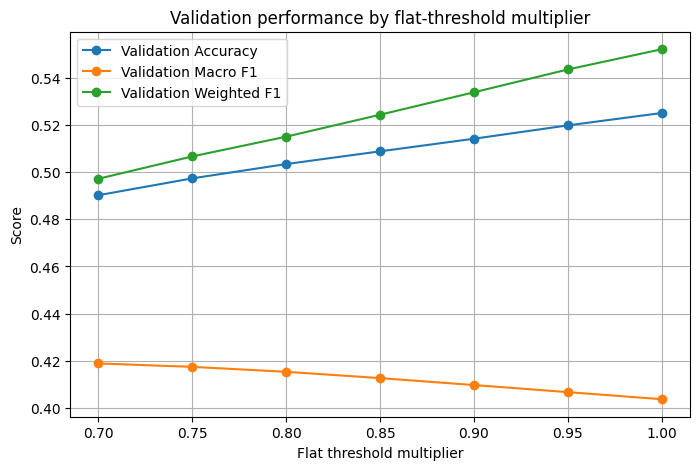

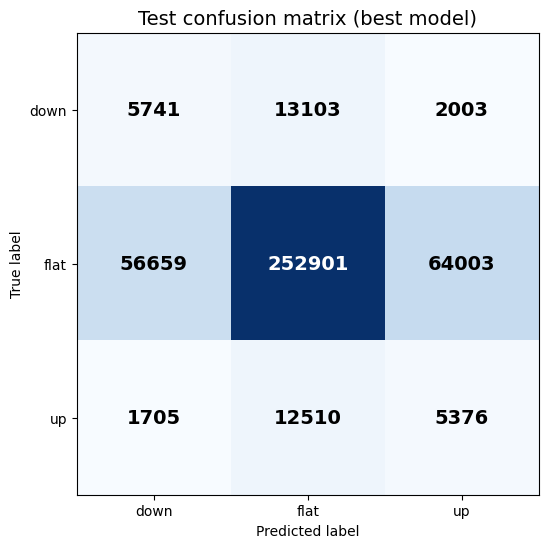

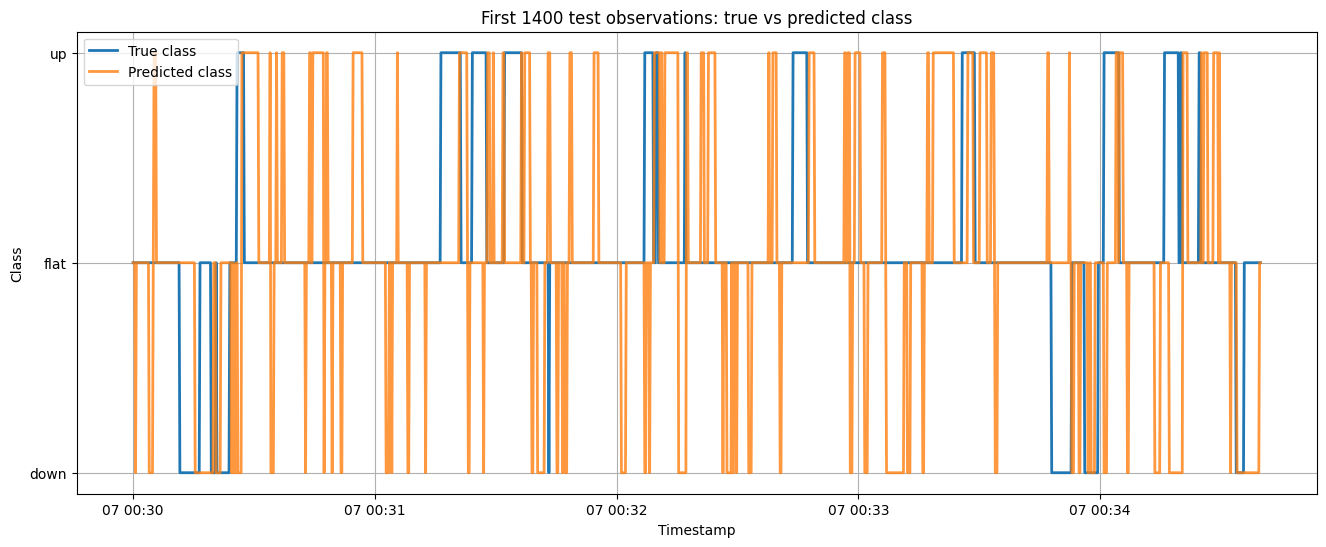

In [31]:
hawkes_cols = [
    "lambda_up",
    "lambda_down",
    "lambda_buy",
    "lambda_sell",
    "lambda_bybit_up",
    "lambda_bybit_down",
    "lambda_okx_up",
    "lambda_okx_down",
    "lambda_gateio_up",
    "lambda_gateio_down",
    "activity_score",
    "direction_score",
]

print("Summary stats of final Hawkes signals on test:")
print(test_h[hawkes_cols].describe())

final_test_cols = [TS_COL, "date", "split", "y_fwd5s_logret", "y_cls", "pred"] + hawkes_cols
final_test_output = test_h[final_test_cols].copy()
final_test_output.to_parquet(
    OUT_DIR / "Binance_hawkes_twostage_test_predictions_best.parquet",
    index=False
)

print("\nSaved:")
print(OUT_DIR / "Binance_hawkes_twostage_param_search_results.csv")
print(OUT_DIR / "Binance_hawkes_twostage_test_predictions_best.parquet")

# =========================
# VISUALIZATION
# =========================

# 1) accuracy / F1 by flat threshold from validation search
flat_summary = (
    search_df.groupby("flat_mult")[["accuracy", "macro_f1", "weighted_f1"]]
    .max()
    .reset_index()
    .sort_values("flat_mult")
)

display(flat_summary)

plt.figure(figsize=(8, 5))
plt.plot(flat_summary["flat_mult"], flat_summary["accuracy"], marker="o", label="Validation Accuracy")
plt.plot(flat_summary["flat_mult"], flat_summary["macro_f1"], marker="o", label="Validation Macro F1")
plt.plot(flat_summary["flat_mult"], flat_summary["weighted_f1"], marker="o", label="Validation Weighted F1")
plt.xlabel("Flat threshold multiplier")
plt.ylabel("Score")
plt.title("Validation performance by flat-threshold multiplier")
plt.legend()
plt.grid(True)
plt.show()

# 2) Test confusion matrix (best model)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

label_order = [-1, 0, 1]
label_names = ["down", "flat", "up"]

cm = confusion_matrix(test_h["y_cls"], test_h["pred"], labels=label_order)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
    values_format="d"
)

threshold = cm.max() / 2

for text in disp.text_.ravel():
    value = int(text.get_text())
    text.set_color("white" if value > threshold else "black")
    text.set_fontsize(14)
    text.set_fontweight("bold")

ax.set_title("Test confusion matrix (best model)", fontsize=14)
plt.show()

# 3) First 1400 test observations: true vs predicted class
plot_n = min(1400, len(test_h))

plot_df = test_h[[TS_COL, "y_cls", "pred"]].iloc[:plot_n].copy()
plot_df = plot_df.sort_values(TS_COL)

class_to_num = {-1: 0, 0: 1, 1: 2}

y_true_num = plot_df["y_cls"].map(class_to_num)
y_pred_num = plot_df["pred"].map(class_to_num)

plt.figure(figsize=(16, 6))
plt.plot(plot_df[TS_COL], y_true_num, label="True class", linewidth=2)
plt.plot(plot_df[TS_COL], y_pred_num, label="Predicted class", linewidth=2, alpha=0.8)

plt.yticks([0, 1, 2], ["down", "flat", "up"])
plt.xlabel("Timestamp")
plt.ylabel("Class")
plt.title(f"First {plot_n} test observations: true vs predicted class")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# =========================
# CLEAN RESULT VISUALIZATIONS
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

viz_df = test_h.copy().sort_values(TS_COL).reset_index(drop=True)

# =========================
# 1) Normalized confusion matrix
# =========================
label_order = [-1, 0, 1]
label_names = ["down", "flat", "up"]

cm = confusion_matrix(viz_df["y_cls"], viz_df["pred"], labels=label_order)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_norm, cmap="viridis", aspect="auto")

ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names)
ax.set_yticklabels(label_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Normalized test confusion matrix")

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(j, i, f"{cm_norm[i, j]:.3f}", ha="center", va="center", color="white")

fig.colorbar(im, ax=ax)
plt.show()


# =========================
# 2) Short test window: true vs predicted class
# =========================
window_n = min(1400, len(viz_df))
start_idx = 0   # you can change this to inspect a different window

window_df = viz_df.iloc[start_idx:start_idx + window_n].copy()

class_to_num = {-1: 0, 0: 1, 1: 2}

y_true_num = window_df["y_cls"].map(class_to_num)
y_pred_num = window_df["pred"].map(class_to_num)

plt.figure(figsize=(16, 6))
plt.plot(window_df[TS_COL], y_true_num, label="True class", linewidth=2)
plt.plot(window_df[TS_COL], y_pred_num, label="Predicted class", linewidth=2, alpha=0.85)

plt.yticks([0, 1, 2], ["down", "flat", "up"])
plt.xlabel("Timestamp")
plt.ylabel("Class")
plt.title(f"Test window ({window_n} obs): true vs predicted class")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# 3) Boxplot of realized forward return by predicted class
# =========================
box_data = [
    viz_df.loc[viz_df["pred"] == -1, "y_fwd5s_logret"].dropna().values,
    viz_df.loc[viz_df["pred"] == 0, "y_fwd5s_logret"].dropna().values,
    viz_df.loc[viz_df["pred"] == 1, "y_fwd5s_logret"].dropna().values,
]

plt.figure(figsize=(8, 6))
plt.boxplot(box_data, labels=["pred down", "pred flat", "pred up"], showfliers=False)
plt.axhline(0.0, linestyle="--", linewidth=1.5)
plt.ylabel("Realized 5s forward log return")
plt.title("Realized forward return by predicted class (test)")
plt.grid(True, axis="y")
plt.show()


# =========================
# 4) Short test window: activity score / direction score
# =========================
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(window_df[TS_COL], window_df["activity_score"], linewidth=1.8, label="Activity score")
axes[0].axhline(final_activity_thr, linestyle="--", linewidth=1.5, label=f"activity_thr = {final_activity_thr:.4f}")
axes[0].set_ylabel("Activity score")
axes[0].set_title("Short test window: activity score")
axes[0].legend()
axes[0].grid(True)

direction_bias = BEST_PARAMS["direction_bias"]
axes[1].plot(window_df[TS_COL], window_df["direction_score"], linewidth=1.8, label="Direction score")
axes[1].axhline(direction_bias, linestyle="--", linewidth=1.5, label=f"direction_bias = {direction_bias:.4f}")
axes[1].set_ylabel("Direction score")
axes[1].set_xlabel("Timestamp")
axes[1].set_title("Short test window: direction score")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
